# Ocean Acidification: pH

In [1]:
# CIndRA notebook display standard
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'figure.dpi': 100,
    'savefig.dpi': 300,
})

```{glue:figure} average_map
:scale: 50%
:align: center
```

```{glue:figure} average_timeseries
:scale: 50%
:align: center
```

**Figure. Change in pH from hindcast.** The map (top) shows the change in mean surface pH in the vicinity of Palau over the period 1993- 2022. The grey line is the Palau EEZ.  The line plot (bottom) shows the change in mean surface pH averaged over the area within the top plot. The solid black line represents the trend, which is statistically significant (p < 0.05). The colored dots represent the 10 years with the lowest pH on record. [Link to data](https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_BGC_001_029/download?dataset=cmems_mod_glo_bgc_my_0.25deg_P1M-m_202406)

In [2]:
import json
import os.path as op
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

try:
    from myst_nb import glue
except ImportError:
    def glue(name, value, display=False):
        return value

# Locate CIndRA independently of the directory from which Jupyter was started.
root_candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
repo_root = next((p for p in root_candidates if (p / "functions/data_downloaders.py").is_file()), None)
if repo_root is None:
    raise FileNotFoundError("Could not locate the CIndRA repository root.")

indicators_setup_dir = repo_root.parents[1] / "indicators_setup"
if not indicators_setup_dir.is_dir():
    raise FileNotFoundError(f"Shared indicators package not found: {indicators_setup_dir}")
sys.path.insert(0, str(indicators_setup_dir))
sys.path.insert(0, str(repo_root / "functions"))

from ind_setup.plotting_int import plot_timeseries_interactive, plot_oni_index_th
from ind_setup.plotting import (
    plot_base_map, plot_map_subplots, add_oni_cat, plot_bar_probs, fontsize,
)
from data_downloaders import download_ERDDAP_data, download_oni_index
from ocean import process_trend_with_nan
from sst import polygon_mask

# National-site configuration shared with the other indicator families.
site_config_file = repo_root / "data/sites/palau.json"
site_config = json.loads(site_config_file.read_text())
site_name = site_config["site_name"]
country = site_config.get("country", site_name)
site_lon = float(site_config["site_lon"])
site_lat = float(site_config["site_lat"])
loc = [site_lat, site_lon]

data_dir = repo_root / "data"
biochemistry_data_dir = data_dir / "biochemistry"
fig_dir = repo_root / "matrix_cc/figures"
biochemistry_data_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
path_data = biochemistry_data_dir
path_figs = fig_dir

eez_file = data_dir / "Palau_EEZ/pw_eez_pol_april2022.shp"
shp_eez = gpd.read_file(eez_file).to_crs(4326)
xmin, ymin, xmax, ymax = shp_eez.total_bounds
lon_range = [float(xmin), float(xmax)]
lat_range = [float(ymin), float(ymax)]

def mask_dataset_to_eez(dataset):
    """Mask a latitude/longitude dataset to cell centres inside the selected EEZ."""
    geometry = shp_eez.geometry.unary_union
    mask = polygon_mask(geometry, np.asarray(dataset.longitude), np.asarray(dataset.latitude)).rename(
        {"lon": "longitude", "lat": "latitude"}
    )
    return dataset.where(mask)

print(f"Site: {site_name} ({site_lat:.3f}°N, {site_lon:.3f}°E)")
print(f"Biochemistry data: {biochemistry_data_dir}")


Site: Palau (7.340°N, 134.620°E)
Biochemistry data: /Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/CIndRA/data/biochemistry


## Setup

Define area of interest

In [3]:
# Area of interest derived from the configured EEZ
print(f"Longitude: {lon_range}; latitude: {lat_range}")


Longitude: [129.508805, 136.994722]; latitude: [1.621407, 11.558725]


EEZ shapefile

In [4]:
path_figs = fig_dir

In [5]:
shp_f = eez_file
print(f"EEZ: {shp_f}")

EEZ: /Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/CIndRA/data/Palau_EEZ/pw_eez_pol_april2022.shp


### Load Data

In [6]:
data_xr = xr.open_dataset(biochemistry_data_dir / 'data_phyc_o2_ph.nc')
dataset_id = 'ph'
label = 'pH'

if 'depth' in data_xr.dims:
    data_xr = data_xr.isel(depth=0, drop=True)
data_xr = mask_dataset_to_eez(data_xr)
print(f"{dataset_id}: {str(data_xr.time.min().values)[:10]} to {str(data_xr.time.max().values)[:10]}")


ph: 1993-01-01 to 2025-11-01


In [7]:
# data_xr = xr.open_dataset(op.join(os.getcwd(), '..', '..','..', 'data/data_phyc_o2_ph_2022.nc')).isel(depth = 0).drop('depth')
# data_2025 = xr.open_dataset('/Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/CC_indicators/data/cmems_mod_glo_bgc_my_0.25deg_P1M-m_1768393001661_2024_2025.nc')
# data_xr = data_xr.merge(data_2025.sel(longitude = data_xr.longitude, latitude = data_xr.latitude).isel(depth = 0).drop('depth'))
# data_xr.to_netcdf(op.join(os.getcwd(), '..', '..','..', 'data/data_phyc_o2_ph.nc'))
# data_xr 

## Analysis

### Plotting

#### Average

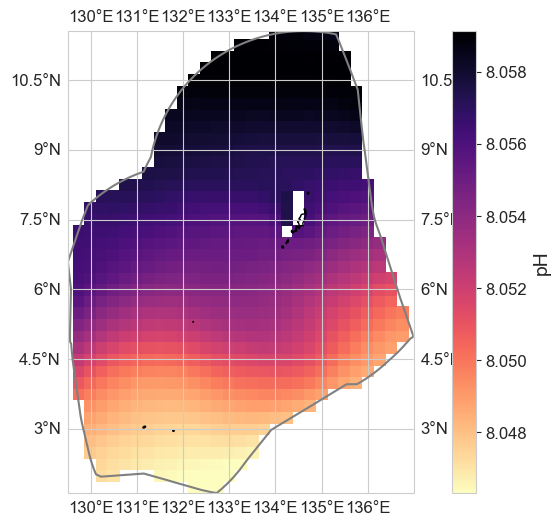

In [8]:
fig, ax = plot_base_map(shp_eez = shp_eez, figsize = [10, 6])
im = ax.pcolor(data_xr.longitude, data_xr.latitude, data_xr.mean(dim='time')[dataset_id], transform=ccrs.PlateCarree(), 
                cmap = 'magma_r', 
                vmin = np.nanpercentile(data_xr.mean(dim = 'time')[dataset_id], 1), 
                vmax = np.nanpercentile(data_xr.mean(dim = 'time')[dataset_id], 99))
ax.set_extent([lon_range[0], lon_range[1], lat_range[0], lat_range[1]], crs=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label= label)
glue("average_map", fig, display=False)
plt.savefig(op.join(path_figs, 'F14_pH_mean_map.png'), dpi=300, bbox_inches='tight')


#### Change

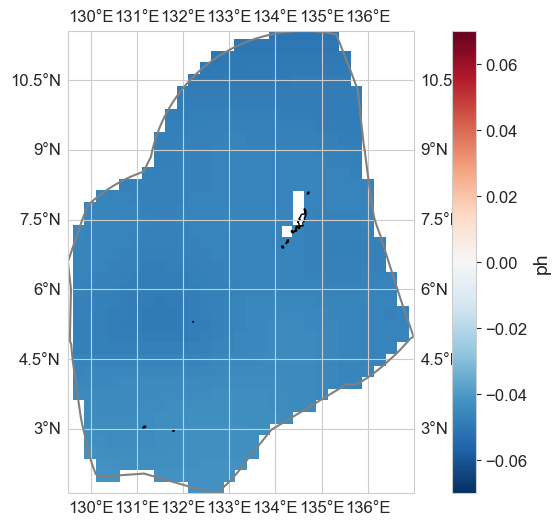

In [9]:
trend_m, _, _, _, _ = process_trend_with_nan(data_xr[dataset_id])

fig, ax = plot_base_map(shp_eez = shp_eez, figsize = [10, 6])
im = ax.pcolor(data_xr.longitude, data_xr.latitude, 
               trend_m,
                transform=ccrs.PlateCarree(), 
                cmap = 'RdBu_r', 
                vmin = -.07,
                vmax = .07,
                )
ax.set_extent([lon_range[0], lon_range[1], lat_range[0], lat_range[1]], crs=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label=  dataset_id)
plt.savefig(op.join(path_figs, 'F14_pH_mean_map_trend.png'), dpi=300, bbox_inches='tight')

#### Seasonal average

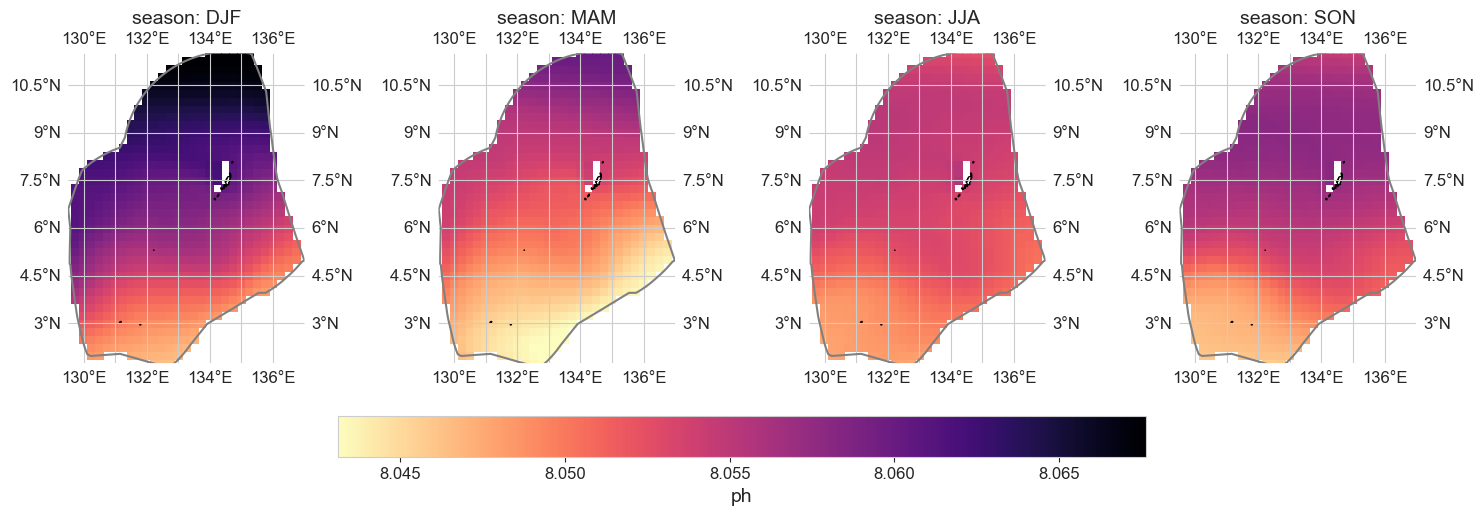

In [10]:
data_month = data_xr.groupby('time.season').mean().sel(season = ['DJF', 'MAM', 'JJA', 'SON'])
im = plot_map_subplots(data_month, dataset_id, shp_eez = shp_eez, cmap = 'magma_r', 
                  vmin = np.nanpercentile(data_month.min(dim = 'season')[dataset_id], 1), 
                  vmax = np.nanpercentile(data_month.max(dim = 'season')[dataset_id], 99),
                  figsize = (15,11), sub_plot = [1, 4], cbar_pad = 0.05,
                  cbar = 1)

#### Seasonal anomaly

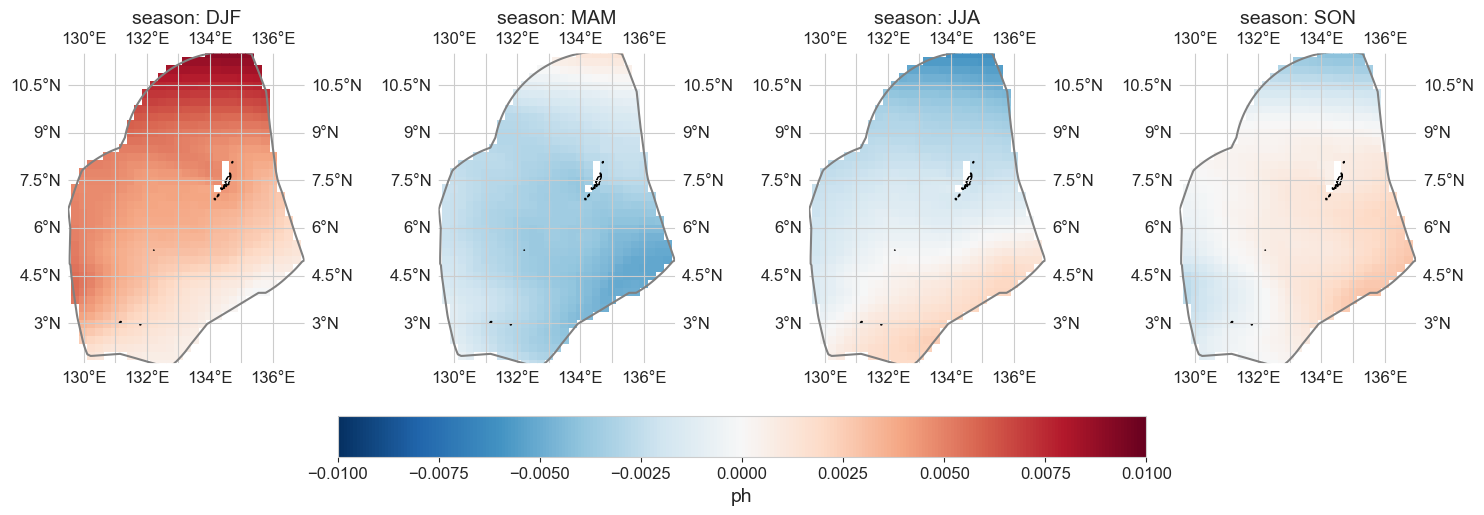

In [11]:
data_month = data_xr.groupby('time.season').mean().sel(season = ['DJF', 'MAM', 'JJA', 'SON']) - data_xr.mean(dim='time')
im = plot_map_subplots(data_month, dataset_id, shp_eez = shp_eez, 
                  cmap = 'RdBu_r', vmin=-.01, vmax=.01,
                  figsize = (15,11), sub_plot = [1, 4], cbar_pad = 0.05,
                  cbar = 1)

#### Annual average

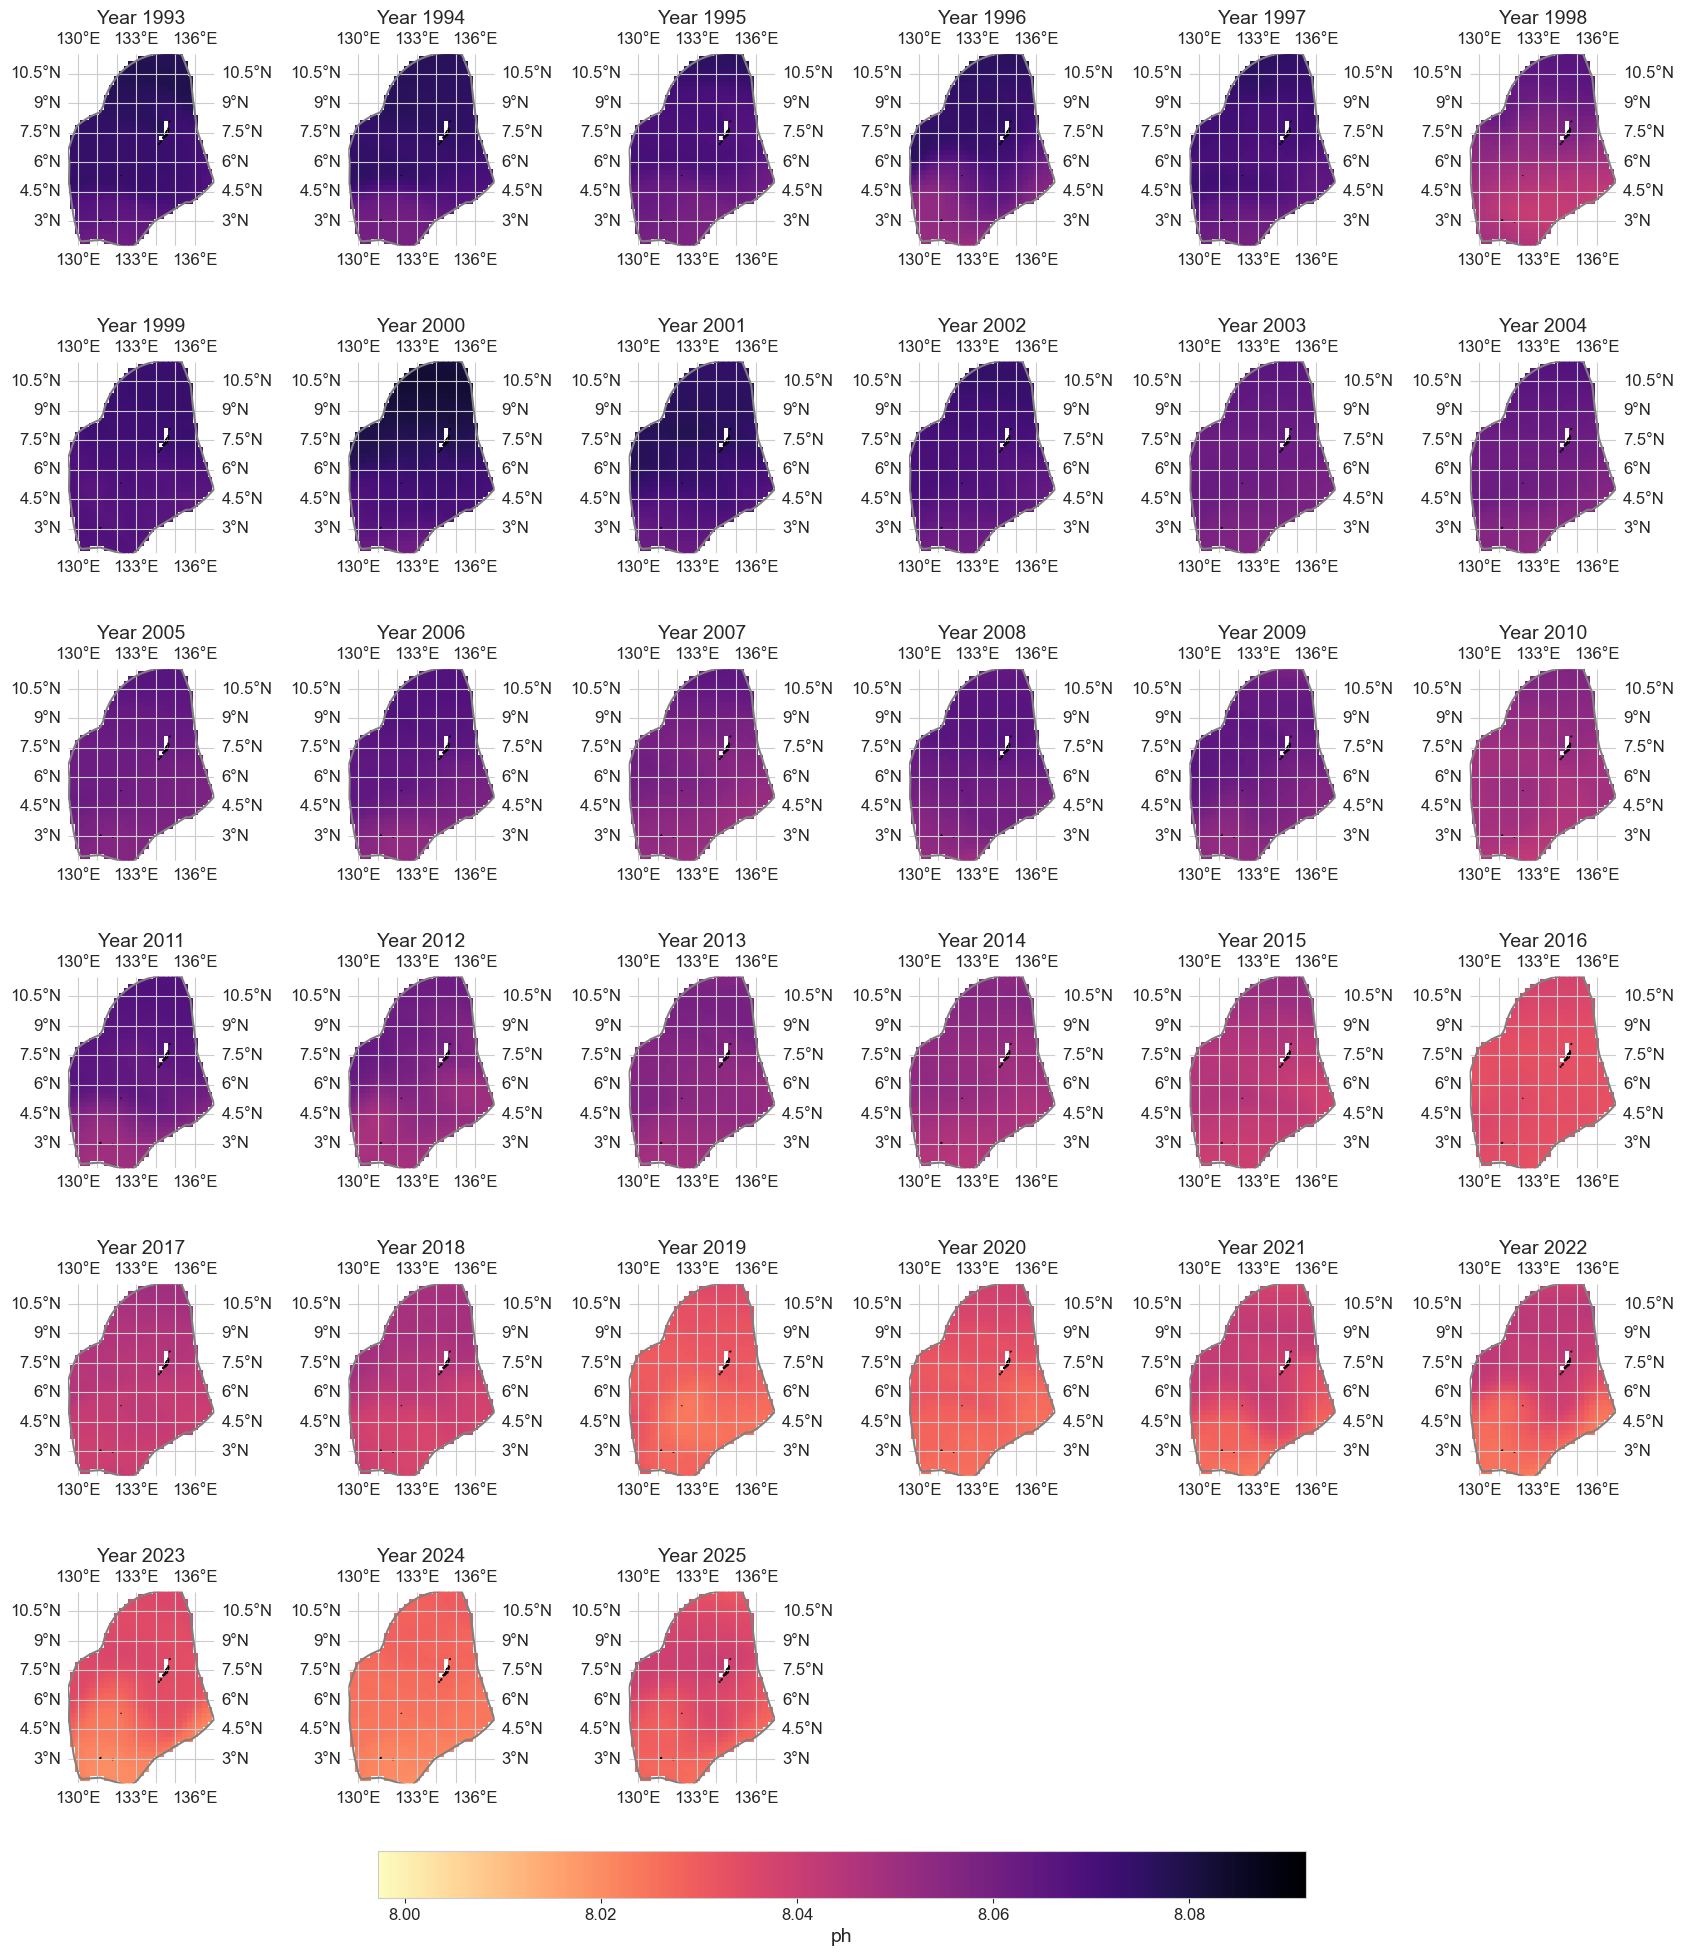

In [12]:
data_y = data_xr.resample(time='1YE').mean()
im = plot_map_subplots(data_y, dataset_id, shp_eez = shp_eez, cmap = 'magma_r', 
                  vmin = np.nanpercentile(data_xr.min(dim = 'time')[dataset_id], 1), 
                  vmax = np.nanpercentile(data_xr.max(dim = 'time')[dataset_id], 99),
                  cbar = 1)

#### Annual anomaly

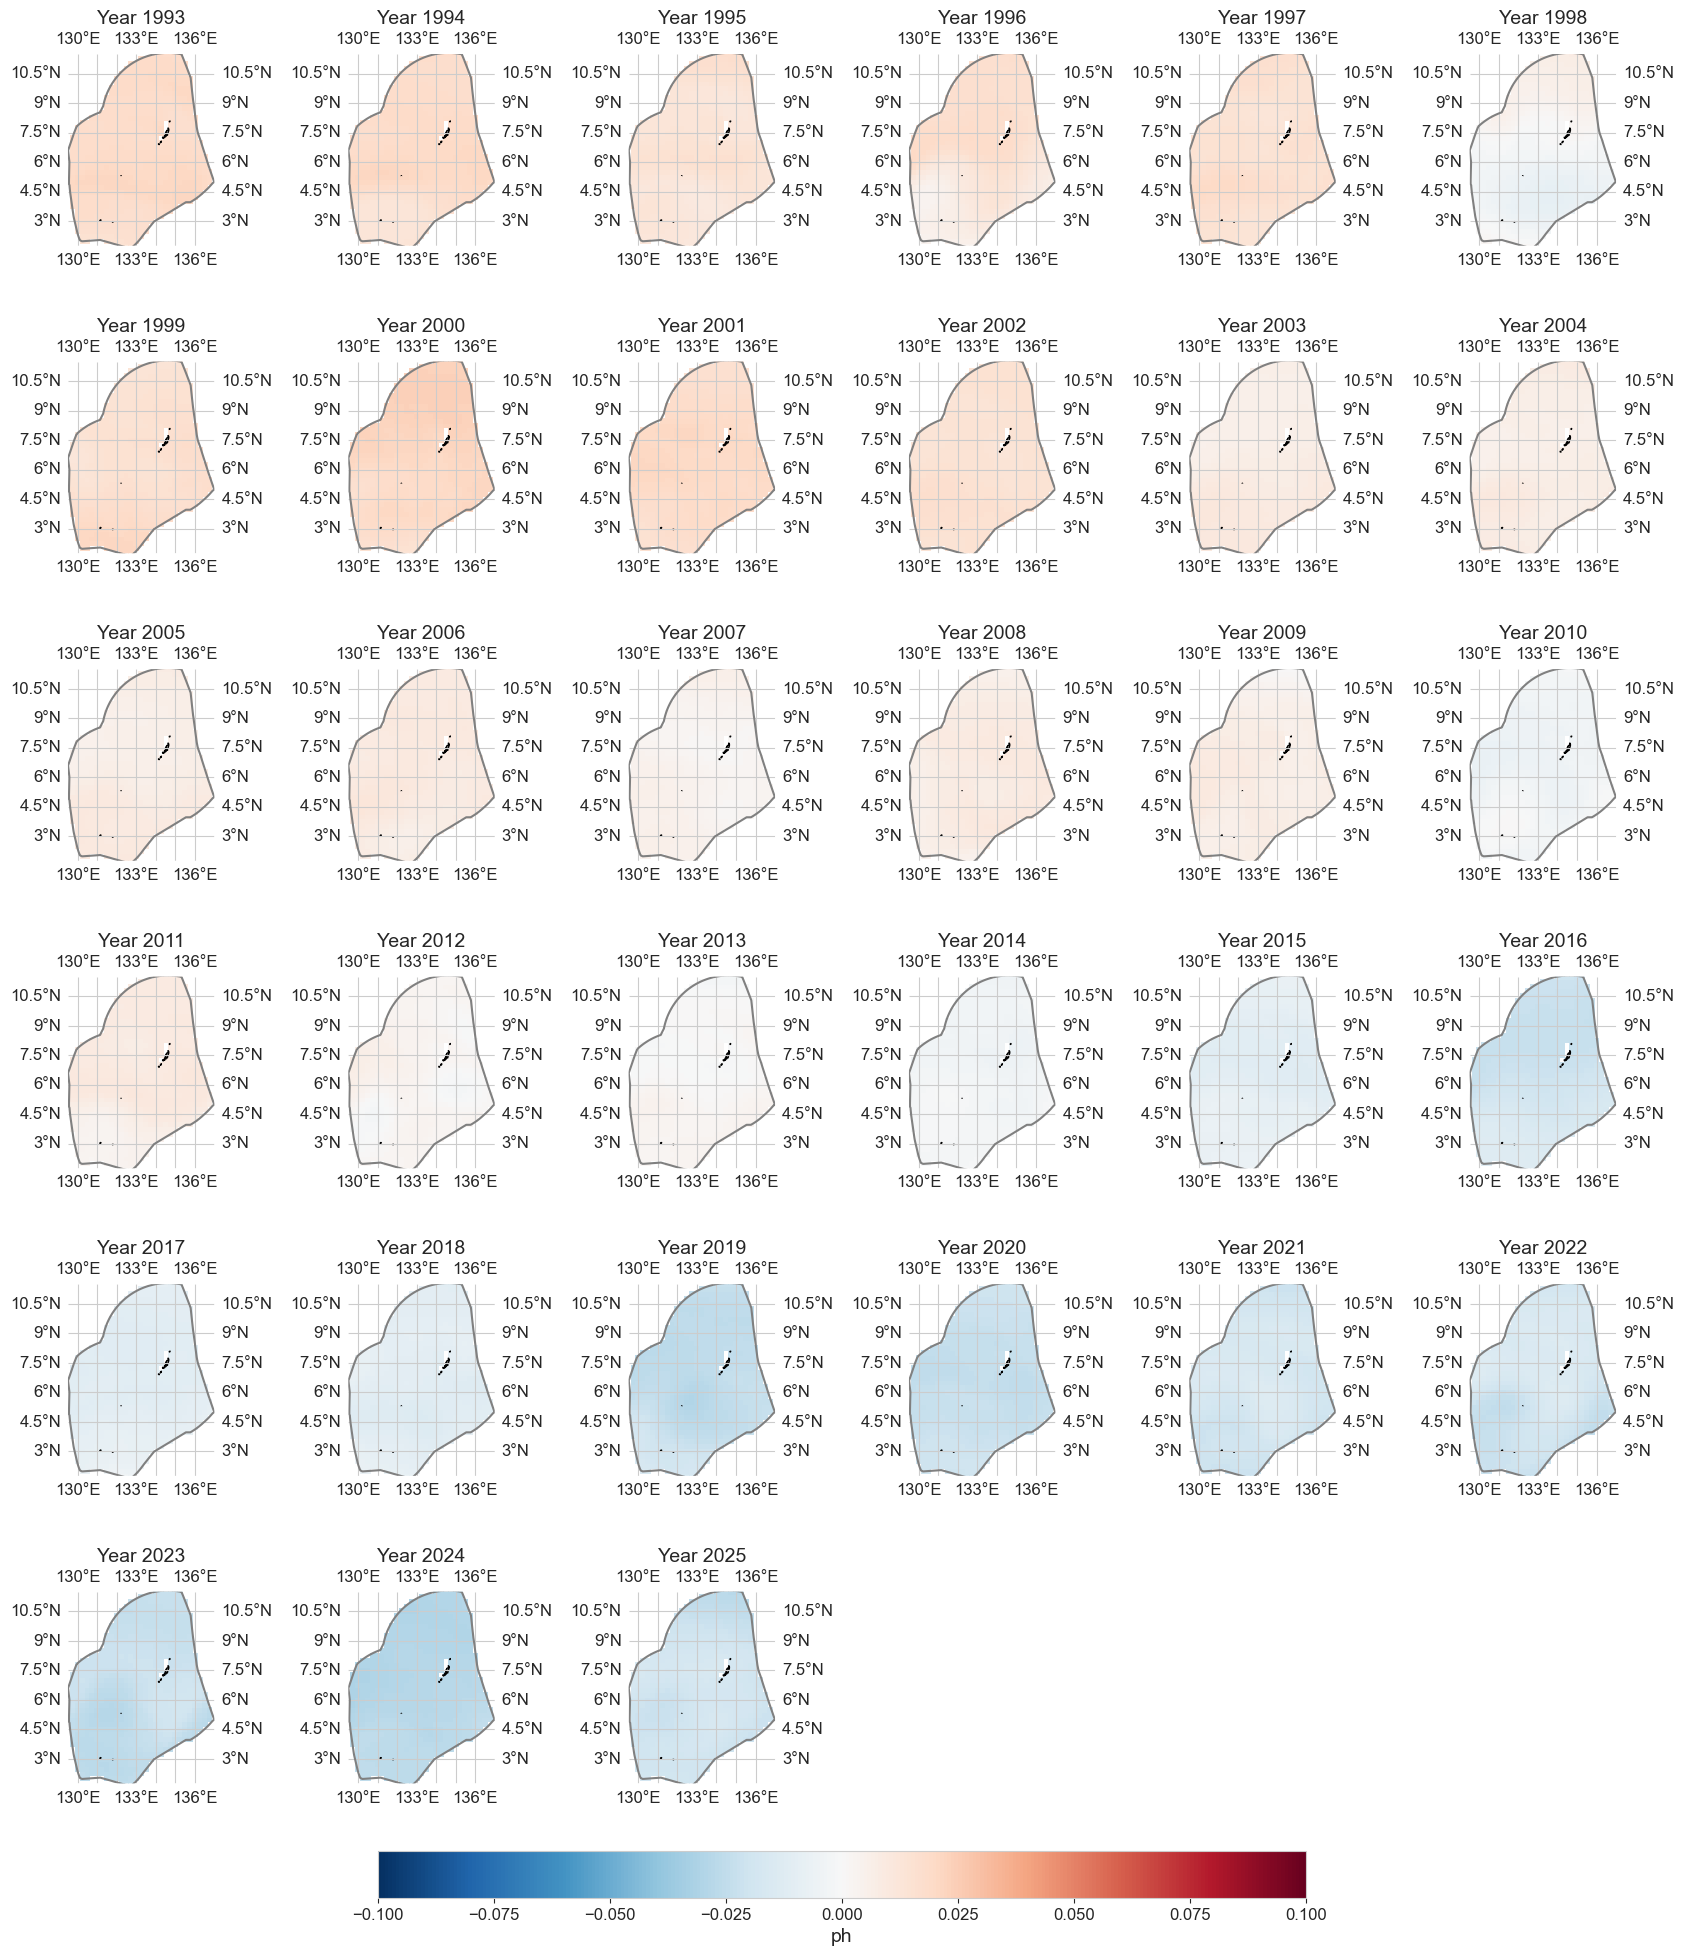

In [13]:
data_an = data_y - data_xr.mean(dim='time')
fig = plot_map_subplots(data_an, dataset_id, shp_eez = shp_eez, cmap='RdBu_r', vmin=-.1, vmax=.1, cbar = 1)

#### Average over area

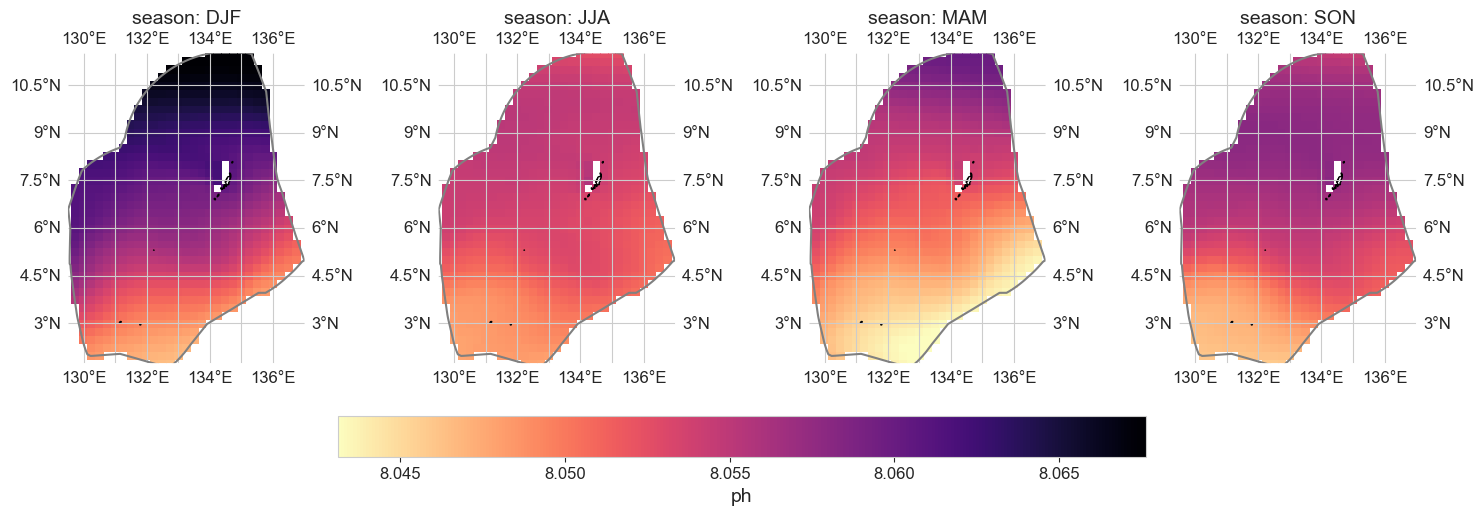

In [14]:
data_month = data_xr.groupby('time.season').mean()
im = plot_map_subplots(data_month, dataset_id, shp_eez = shp_eez, cmap = 'magma_r', 
                  vmin = np.nanpercentile(data_month.min(dim = 'season')[dataset_id], 1), 
                  vmax = np.nanpercentile(data_month.max(dim = 'season')[dataset_id], 99),
                  figsize = (15,11), sub_plot = [1, 4], cbar_pad = 0.05,
                  cbar = 1)

In [15]:
dict_plot = [{'data' : data_xr.mean(dim = ['longitude', 'latitude']).to_dataframe(), 
              'var' : dataset_id, 'ax' : 1, 'label' : 'pH - MEAN AREA'},]

In [16]:
fig, trend = plot_timeseries_interactive(dict_plot, trendline=True, scatter_dict = None, return_trend=True, figsize = (25, 12));
fig.write_html(op.join(path_figs, 'F14_pH_mean_trend.html'), include_plotlyjs="cdn")
fig.write_image(op.join(path_figs, 'F14_pH_mean_trend.png'), width=1200, height=600,)

#### Seasonal average

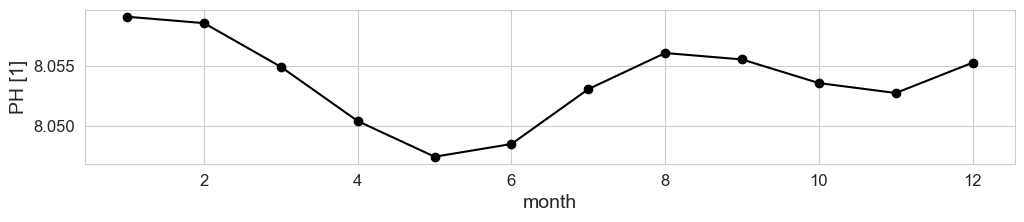

In [17]:
fig, ax = plt.subplots(figsize=(12,2))
data_xr.mean(dim = ['longitude', 'latitude']).groupby('time.month').mean()[dataset_id].plot(ax = ax, marker = 'o', color = 'k')

#### Timeseries at a given point

In [18]:
# Point comes from the selected national site configuration.
dict_plot = [{'data' : data_xr.sel(longitude=loc[1], latitude=loc[0], method='nearest').to_dataframe(), 
              'var' : dataset_id, 'ax' : 1, 'label' : f'{label} at [{loc[0]}, {loc[1]}]'},]

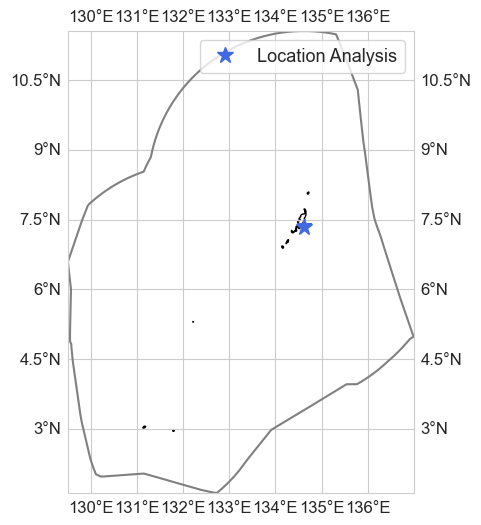

In [19]:
fig, ax = plot_base_map(shp_eez = shp_eez, figsize = [10, 6])
ax.set_extent([lon_range[0], lon_range[1], lat_range[0], lat_range[1]], crs=ccrs.PlateCarree())
ax.plot(loc[1], loc[0], '*', markersize = 12, color = 'royalblue', transform=ccrs.PlateCarree(), label = 'Location Analysis')
ax.legend()

In [20]:
fig = plot_timeseries_interactive(dict_plot, trendline=True, scatter_dict = None, figsize = (25, 12));

### ONI index analysis

In [21]:
p_data = 'https://psl.noaa.gov/data/correlation/oni.data'
df1 = download_oni_index(p_data)

In [22]:
lims = [-.5, .5]
plot_oni_index_th(df1, lims = lims)

Group by ONI category

In [23]:

df1 = add_oni_cat(df1, lims = lims)
df1['ONI'] = df1['oni_cat']
data_xr['ONI'] = (('time'), df1.iloc[np.intersect1d(data_xr.time, df1.index, return_indices=True)[2]].ONI.values)
data_xr['ONI_cat'] = (('time'), np.where(data_xr.ONI < lims[0], -1, np.where(data_xr.ONI > lims[1], 1, 0)))
data_oni = data_xr.groupby('ONI_cat').mean()

#### Average

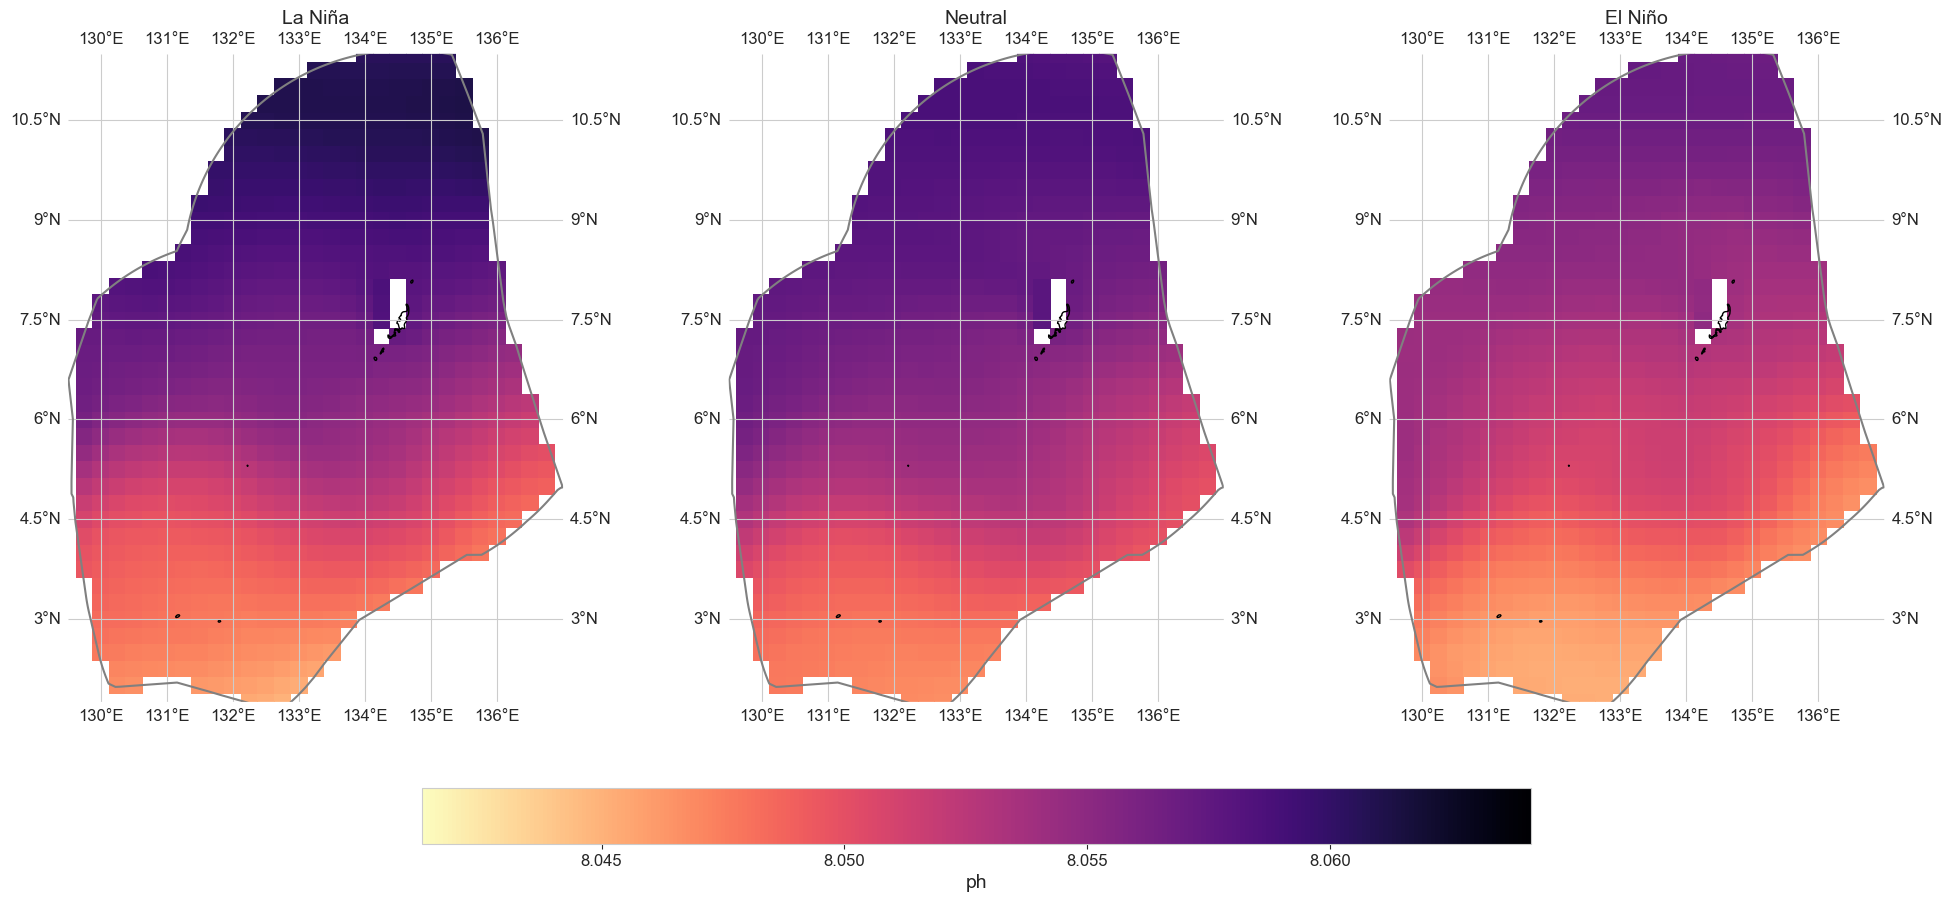

In [24]:
fig = plot_map_subplots(data_oni, dataset_id, shp_eez = shp_eez, cmap = 'magma_r', 
                  vmin = np.nanpercentile(data_xr.mean(dim = 'time')[dataset_id], 1)-.005, 
                  vmax = np.nanpercentile(data_xr.mean(dim = 'time')[dataset_id], 99) + .005,
                  sub_plot= [1, 3], figsize = (20, 9), cbar = True, cbar_pad = 0.1,
                  titles = ['La Niña', 'Neutral', 'El Niño'],)

plt.savefig(op.join(path_figs, 'F14_pH_ENSO.png'), dpi=300, bbox_inches='tight')


#### Anomaly

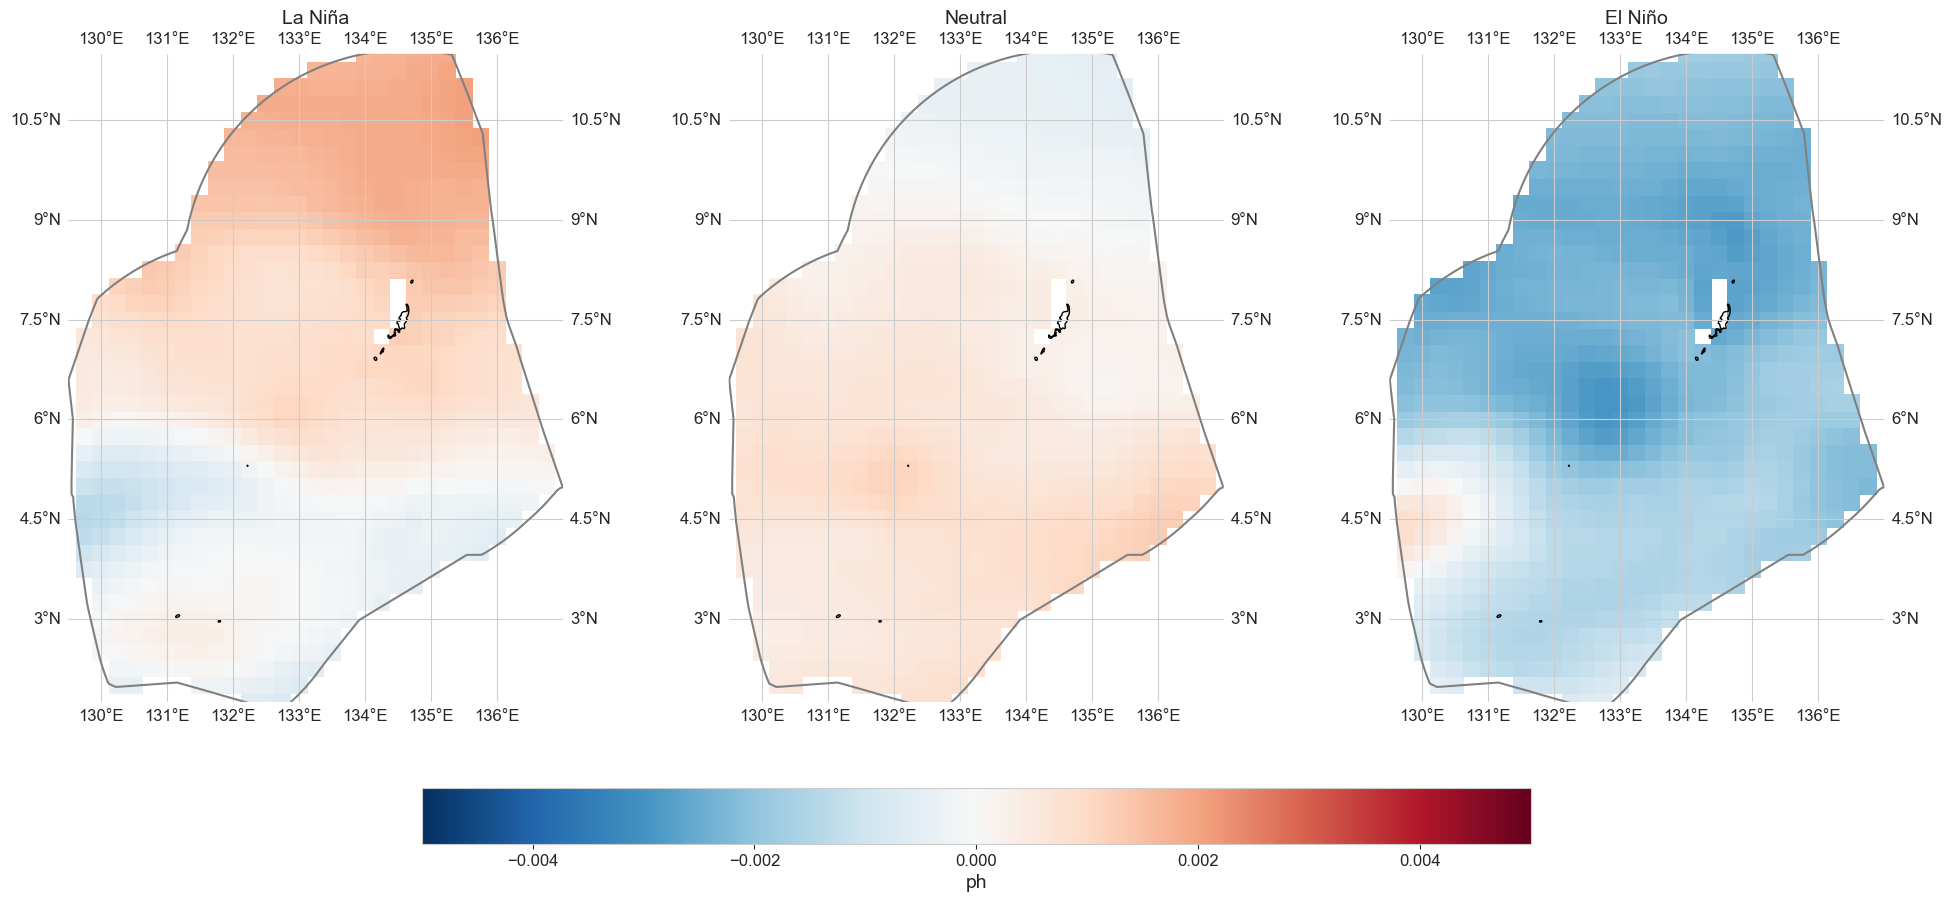

In [25]:
data_an = data_oni - data_xr.mean(dim='time')
fig = plot_map_subplots(data_an, dataset_id, shp_eez = shp_eez, cmap='RdBu_r', vmin=-.005, vmax=.005,
                  sub_plot= [1, 3], figsize = (20, 9), cbar = True, cbar_pad = 0.1,
                  titles = ['La Niña', 'Neutral', 'El Niño'],)

## Table

In [26]:
from ind_setup.tables import style_matrix, table_ocean
style_matrix(table_ocean(data_xr, trend[0], data_oni, dataset_id))

Metric,Value
Monthly Average,8.054
Monthly Maximum 01/09/1994,8.080
Monthly Minimum 01/05/2019,8.017
Maximum Annual Average,8.075
Minimum Annual Average,8.026
Rate of change [pH/year],-0.001
Change between 1993 and 2025 [pH],-0.032
,
Average La Niña ph,8.054
Average El Niño ph,8.052


## Interpretation and reproducibility notes

- Results apply to the configured station, site or EEZ and should not be generalized without checking spatial representativeness.
- Product resolution, depth, model or satellite origin and temporal coverage differ among biogeochemical variables and must be considered in comparisons.
- Linear trends are descriptive unless the notebook explicitly accounts for temporal autocorrelation and other statistical assumptions.
- Confirm the printed source, analysis period, reference period and output paths before using figures or tables in reporting.